# Esercitazione 3

In [1111]:
import numpy as np
import matplotlib.pyplot as plt

## Variabili indipendenti 

Devo generare due set di dati tali che abbiamo due valori di aspettazione diversi, ma stessa varianza. Inoltre per questa parte assumo l'indipendenza. 

In [1112]:
#funzione gaussiana

def gaussian_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [1113]:
# funzione Q^2 per distribuzione multinormale
def Q2_multinormal(x, y, mu, sigma, r):
    return 1/(1-r)*(((x - mu[0])**2 / sigma[0]**2) + ((y - mu[1])**2 / sigma[1]**2) - (2*r*(x - mu[0])*(y - mu[1])/(sigma[0]*sigma[1])))

In [1114]:
# plot Gaussiane multiple con barre di errore

def plot_histo_gauss_mult(titolo, dati, mu, sigma, bins=80):
    fig, axes = plt.subplots(1, 2, figsize=(10,5))

    colors= ['orange', 'blue']
    datasets = dati
    titles = ['L1', 'L2']
    mu = mu
    sigma= sigma

    for ax, data, t, mu, sigma, colors in zip(axes, datasets, titles, mu, sigma, colors):
        # calcolo istogramma senza disegnare subito
        h, bin_edges = np.histogram(data, bins=bins, range= (mu-4*sigma, mu+4*sigma))
        delta_x = bin_edges[1] - bin_edges[0]
        centri = (bin_edges[:-1] + bin_edges[1:]) / 2

        # disegno istogramma
        ax.bar(centri, h, width=delta_x, color= colors,  alpha=0.6, label='Dati')

        # barre di errore Poisson
        ax.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2,
                    fmt='none', color='grey', lw=1, label='Errore Standard')

        # curva normale standard (PDF moltiplicata per n*Δx)
        ax.plot(centri, gaussian_pdf(centri, mu, sigma)*len(data)*delta_x,
                color='red', label='Normale standard')
        ax.set_title(t)
        ax.set_xlabel('x')
        ax.set_ylabel('Conteggi')
        ax.legend(fontsize=8)

    fig.suptitle(titolo)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [1115]:
#calcolo della covarianza

def cov(x, y, mu): 
    return np.sum((x-mu[0])*(y-mu[1]))/(len(x)-1)

In [1116]:
# calcolo coeff di correlazione

def corr(x, y, mu):
    return cov(x, y, mu)/np.sqrt(cov(x, x, [mu[0], mu[0]])*cov(y, y, [mu[1], mu[1]]))

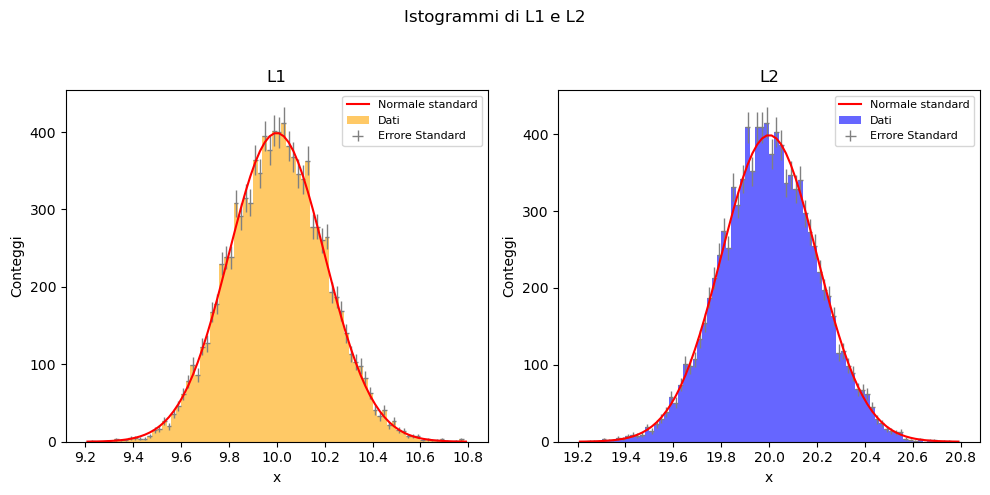

In [1117]:
N=int(1e4)
mu =[10, 20] #m
sigma =[0.2, 0.2] #m

L= [np.random.normal(mu[0], sigma[0], N), np.random.normal(mu[1], sigma[1], N) ]

plot_histo_gauss_mult('Istogrammi di L1 e L2', L, mu, sigma)


### calcolo delle covarianza e del coefficiente di correlazione

In [1118]:
print(f"La covarianza tra le due misura risulta essere {cov(L[0], L[1], mu):g}")
print(f"La deviazione standard della prima misura risulta essere {np.sqrt(cov(L[0], L[0], [mu[0], mu[0]])):g}")
print(f"La deviazione standard della seconda misura risulta essere {np.sqrt(cov(L[1], L[1], [mu[1], mu[1]])):g}")
print(f"Il coeff. di correlazione ρ tra le due misure risulta essere {corr(L[0], L[1], mu):g}")

La covarianza tra le due misura risulta essere 0.000430675
La deviazione standard della prima misura risulta essere 0.200355
La deviazione standard della seconda misura risulta essere 0.199943
Il coeff. di correlazione ρ tra le due misure risulta essere 0.0107509


Il rapporto tra i punti con $Q^2 <1$ e il totale è: 0.3903


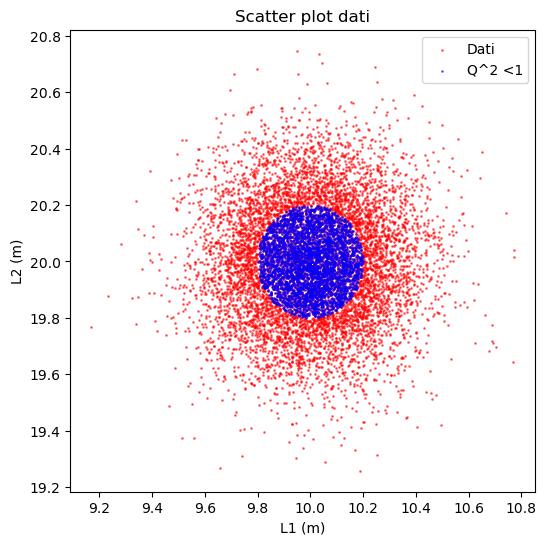

In [1119]:

lista = np.where(Q2_multinormal(L[0], L[1], mu, sigma,0) < 1)


plt.figure(figsize=(6,6))
plt.scatter(L[0], L[1], alpha=0.5, color='red', label='Dati', s=1)
plt.scatter(L[0][lista], L[1][lista], alpha=0.5, color= 'blue', label='Q^2 <1', s=1)
plt.xlabel('L1 (m)')
plt.ylabel('L2 (m)')
plt.title('Scatter plot dati')
plt.legend()

print(r"Il rapporto tra i punti con $Q^2 <1$ e il totale è:" , f"{len(L[0][lista])/len(L[0]):g}")


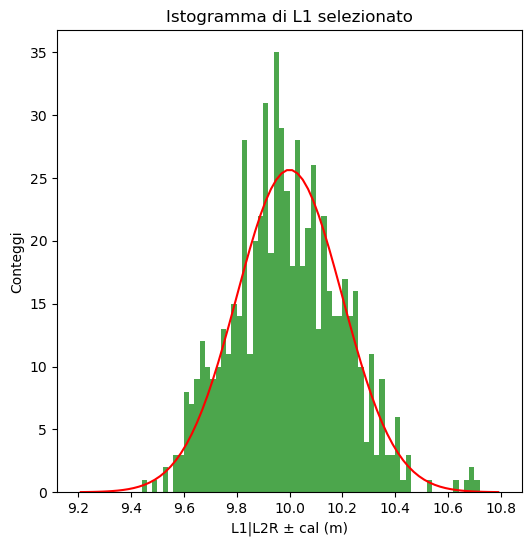

In [1120]:


L2R= 19.7
tolleranza = 0.05

lista_2 = np.where(np.abs(L[1] - L2R) < tolleranza)
L1_selected= L[0][lista_2]

h, bin_edges = np.histogram(L1_selected, bins=80, range= (mu[0]-4*sigma[0], mu[0]+4*sigma[0]))
delta_x = bin_edges[1] - bin_edges[0] 
centri = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(6,6))
plt.bar(centri, h, width=delta_x, color='green', alpha=0.7)
plt.plot(centri, gaussian_pdf(centri, mu[0], sigma[0])*len(L1_selected)*delta_x, color='red', label='Normale standard')
plt.xlabel('L1|L2R ± cal (m)')
plt.ylabel('Conteggi')
plt.title('Istogramma di L1 selezionato')
plt.show()

## Caso di variabili correlate

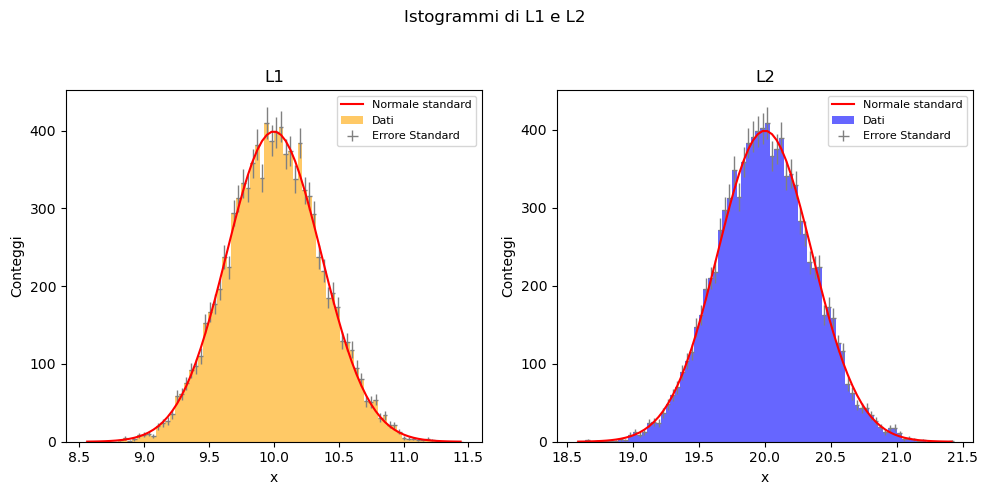

Diff tra varianze calcolate e teoriche è: -0.04, -0.04


In [1121]:
N= int(1e4)

sigma_s_int= 0.3
S = np.random.normal(0, sigma_s_int, N)
mu =[10, 20] #m
sigma =[0.2, 0.2] #m

L_s = [np.random.normal(mu[0], sigma[0], N) + S , np.random.normal(mu[1], sigma[1], N) + S ]
var_s = [(cov(L_s[0], L_s[0], [mu[0], mu[0]])), (cov(L_s[1], L_s[1], [mu[1], mu[1]]))]
sigma_s = [np.sqrt(cov(L_s[0], L_s[0], [mu[0], mu[0]])), np.sqrt(cov(L_s[1], L_s[1], [mu[1], mu[1]]))]

plot_histo_gauss_mult('Istogrammi di L1 e L2', L_s, mu, sigma_s)

diff = np.array(var_s) - np.array(sigma)**2 - np.array(sigma_s)**2
print(f"Diff tra varianze calcolate e teoriche è: {diff[0]:g}, {diff[1]:g}")

## Calcolare covarianza e coeff. di correlazione

In [1122]:
print(f"La covarianza tra le due misura risulta essere {cov(L_s[0], L_s[1], mu):g}")
print(f"La deviazione standard della prima misura risulta essere {np.sqrt(cov(L_s[0], L_s[0], [mu[0], mu[0]])):g}")
print(f"La deviazione standard della seconda misura risulta essere {np.sqrt(cov(L_s[1], L_s[1], [mu[1], mu[1]])):g}")
print(f"Il coeff. di correlazione ρ tra le due misure risulta essere {corr(L_s[0], L_s[1], mu):g}")

rho= corr(L_s[0], L_s[1], mu)

La covarianza tra le due misura risulta essere 0.0913423
La deviazione standard della prima misura risulta essere 0.36456
La deviazione standard della seconda misura risulta essere 0.358004
Il coeff. di correlazione ρ tra le due misure risulta essere 0.699867


Il rapporto tra i punti con $Q^2 <1$ e il totale è: 0.2499


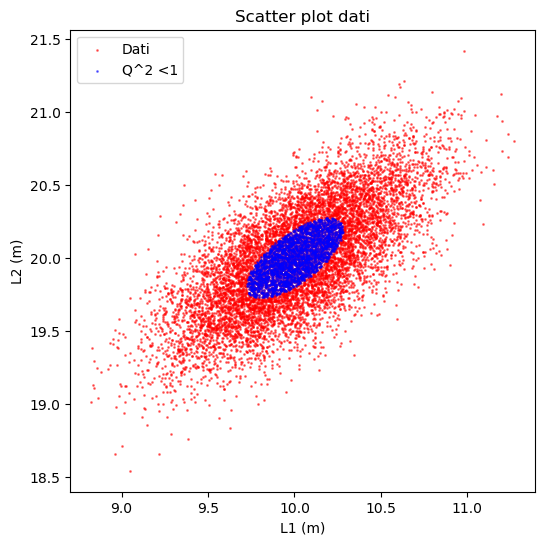

In [1123]:
lista_4 = np.where(Q2_multinormal(L_s[0], L_s[1], mu, sigma_s,rho) < 1)


plt.figure(figsize=(6,6))
plt.scatter(L_s[0], L_s[1], alpha=0.5, color='red', label='Dati', s=1)
plt.scatter(L_s[0][lista_4], L_s[1][lista_4], alpha=0.5, color= 'blue', label='Q^2 <1', s=1)
plt.xlabel('L1 (m)')
plt.ylabel('L2 (m)')
plt.title('Scatter plot dati')
plt.legend()

print(r"Il rapporto tra i punti con $Q^2 <1$ e il totale è:" , f"{len(L_s[0][lista_4])/len(L_s[0]):g}")

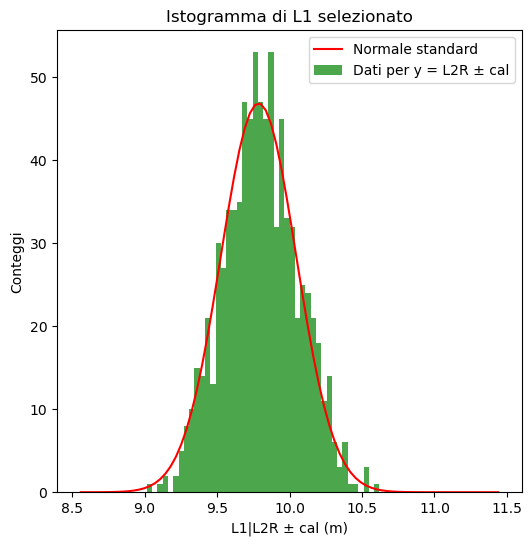

In [1124]:
L2R= 19.7
tolleranza = 0.05

lista_2 = np.where(np.abs(L_s[1] - L2R) < tolleranza)
L1_selected1= L_s[0][lista_2]

h1, bin_edges1 = np.histogram(L1_selected1, bins=80, range= (mu[0]-4*sigma_s[0], mu[0]+4*sigma_s[0]))
delta_x1 = bin_edges1[1] - bin_edges1[0] 
centri1 = (bin_edges1[:-1] + bin_edges1[1:]) / 2

plt.figure(figsize=(6,6))
plt.bar(centri1, h1, width=delta_x1, color='green', alpha=0.7, label='Dati per y = L2R ± cal')
plt.plot(centri1, gaussian_pdf(centri1, mu[0] + rho* sigma_s[0]/sigma_s[1]*(L2R-mu[1]), sigma_s[0]*np.sqrt(1- rho**2))*len(L1_selected1)*delta_x1, color='red', label='Normale standard')
plt.xlabel('L1|L2R ± cal (m)')
plt.ylabel('Conteggi')
plt.title('Istogramma di L1 selezionato')
plt.legend()
plt.show()